# UAS Bengkel Koding - Data Science
## Customer Churn Prediction

**Nama:** Aditya Rendy Setyawan  
**NIM:** A11.2023.15189  
**Kelas:** Bengkel Koding Data Science  

---

### Struktur Tugas:
- **D.1** - Exploratory Data Analysis (EDA)
- **D.2** - Preprocessing Data
- **D.3** - Modeling (3 Algoritma: Logistic Regression, Random Forest, VotingClassifier)
- **D.4** - Hyperparameter Tuning & Evaluasi Lengkap
- **D.5** - Deployment (Streamlit Web App)

**Dataset:** Sales and Marketing DataSet (Kaggle)  
**Target:** `churn` (Binary Classification: 0 = Tidak Churn, 1 = Churn)

---
## Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)

import joblib
import json
import os

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Semua library berhasil di-import!')

Semua library berhasil di-import!


## Load Dataset

In [2]:
# Auto-detect CSV file
csv_files = [f for f in os.listdir('.') if f.endswith('.csv') and 'results' not in f.lower()]
print(f'File CSV ditemukan: {csv_files}')

if csv_files:
    dataset_file = csv_files[0]
else:
    dataset_file = 'Sales and Marketing DataSet.csv'  # fallback name

print(f'Menggunakan dataset: {dataset_file}')
df = pd.read_csv(dataset_file)
print(f'Dataset berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom')

File CSV ditemukan: ['Sales - Marketing customer dataset.csv']
Menggunakan dataset: Sales - Marketing customer dataset.csv
Dataset berhasil dimuat: 15000 baris, 30 kolom


---
# D.1 - Exploratory Data Analysis (EDA)
## D.1.1 Melihat Struktur Data

In [3]:
# Tampilkan 5 data teratas
df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [4]:
# Info dataset
print('='*60)
print('INFORMASI DATASET')
print('='*60)
print(f'Jumlah baris    : {df.shape[0]}')
print(f'Jumlah kolom    : {df.shape[1]}')
print(f'\nTipe data per kolom:')
print(df.dtypes)
print(f'\nDeskripsi statistik:')
df.describe()

INFORMASI DATASET
Jumlah baris    : 15000
Jumlah kolom    : 30

Tipe data per kolom:
customer_id                     int64
gender                         object
age                           float64
country                        object
city                           object
signup_date                    object
last_purchase_date             object
acquisition_channel            object
device_type                    object
subscription_type              object
is_premium_user                 int64
total_visits                    int64
avg_session_time              float64
pages_per_session             float64
email_open_rate               float64
email_click_rate              float64
total_spent                   float64
avg_order_value               float64
discount_used                   int64
coupon_code                    object
support_tickets                 int64
refund_requested                int64
delivery_delay_days             int64
payment_method                 object
sat

,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,10.334384,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,-4.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000


In [5]:
# Info detail
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

## D.1.2 Missing Values Analysis

MISSING VALUES ANALYSIS
                    Missing Count  Percentage (%)
coupon_code                  6133       40.886667
age                          1200        8.000000
total_spent                  1050        7.000000
gender                        738        4.920000
satisfaction_score            702        4.680000

Total kolom dengan missing values: 5


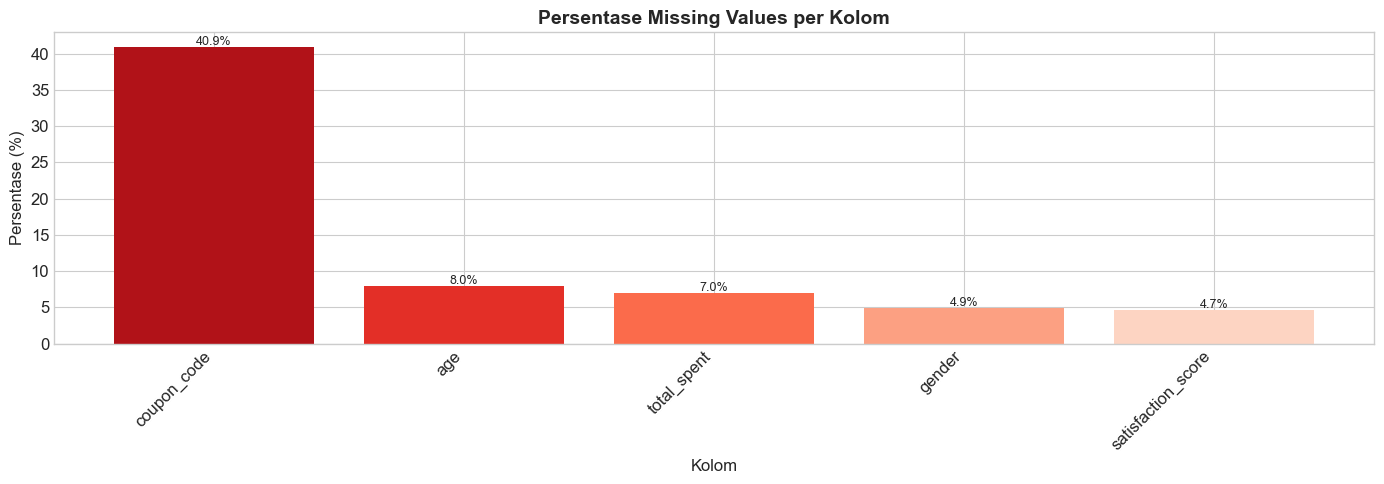

In [6]:
# Cek missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': missing_pct
}).sort_values('Missing Count', ascending=False)

print('='*60)
print('MISSING VALUES ANALYSIS')
print('='*60)
print(missing_df[missing_df['Missing Count'] > 0])
print(f'\nTotal kolom dengan missing values: {(missing > 0).sum()}')

# Visualisasi missing values
if (missing > 0).sum() > 0:
    fig, ax = plt.subplots(figsize=(14, 5))
    missing_cols = missing_df[missing_df['Missing Count'] > 0]
    bars = ax.bar(missing_cols.index, missing_cols['Percentage (%)'], color=sns.color_palette('Reds_r', len(missing_cols)))
    ax.set_title('Persentase Missing Values per Kolom', fontsize=14, fontweight='bold')
    ax.set_ylabel('Persentase (%)')
    ax.set_xlabel('Kolom')
    plt.xticks(rotation=45, ha='right')
    for bar, val in zip(bars, missing_cols['Percentage (%)']):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3, f'{val:.1f}%', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('\nTidak ada missing values!')

## D.1.3 Distribusi Target (Churn)

DISTRIBUSI TARGET (CHURN)
Tidak Churn (0): 12702 (84.7%)
Churn (1)      : 2298 (15.3%)
Rasio Imbalance : 5.5:1


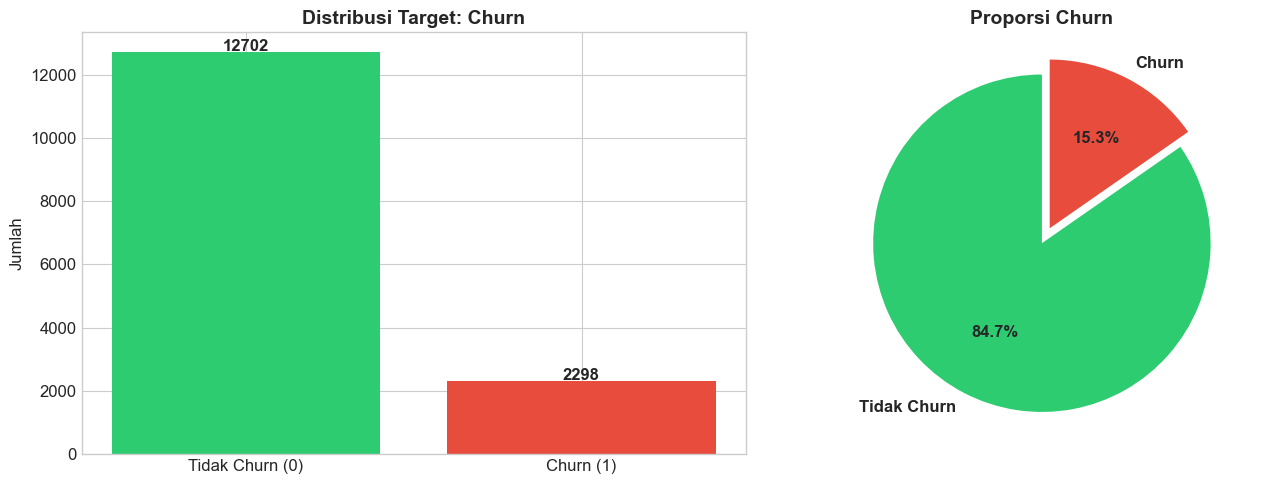


[WARNING] Dataset TIDAK SEIMBANG (imbalanced)! Akan menggunakan class_weight="balanced" saat modeling.


In [7]:
# Distribusi target variable
churn_counts = df['churn'].value_counts()
churn_pct = df['churn'].value_counts(normalize=True) * 100

print('='*60)
print('DISTRIBUSI TARGET (CHURN)')
print('='*60)
print(f'Tidak Churn (0): {churn_counts[0]} ({churn_pct[0]:.1f}%)')
print(f'Churn (1)      : {churn_counts[1]} ({churn_pct[1]:.1f}%)')
print(f'Rasio Imbalance : {churn_counts[0]/churn_counts[1]:.1f}:1')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Tidak Churn (0)', 'Churn (1)'], churn_counts.values, color=colors)
axes[0].set_title('Distribusi Target: Churn', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Tidak Churn', 'Churn'], autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0, 0.1),
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Proporsi Churn', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\n[WARNING] Dataset TIDAK SEIMBANG (imbalanced)! Akan menggunakan class_weight="balanced" saat modeling.')

## D.1.4 Distribusi Fitur Numerik

Fitur numerik (18): ['age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq']


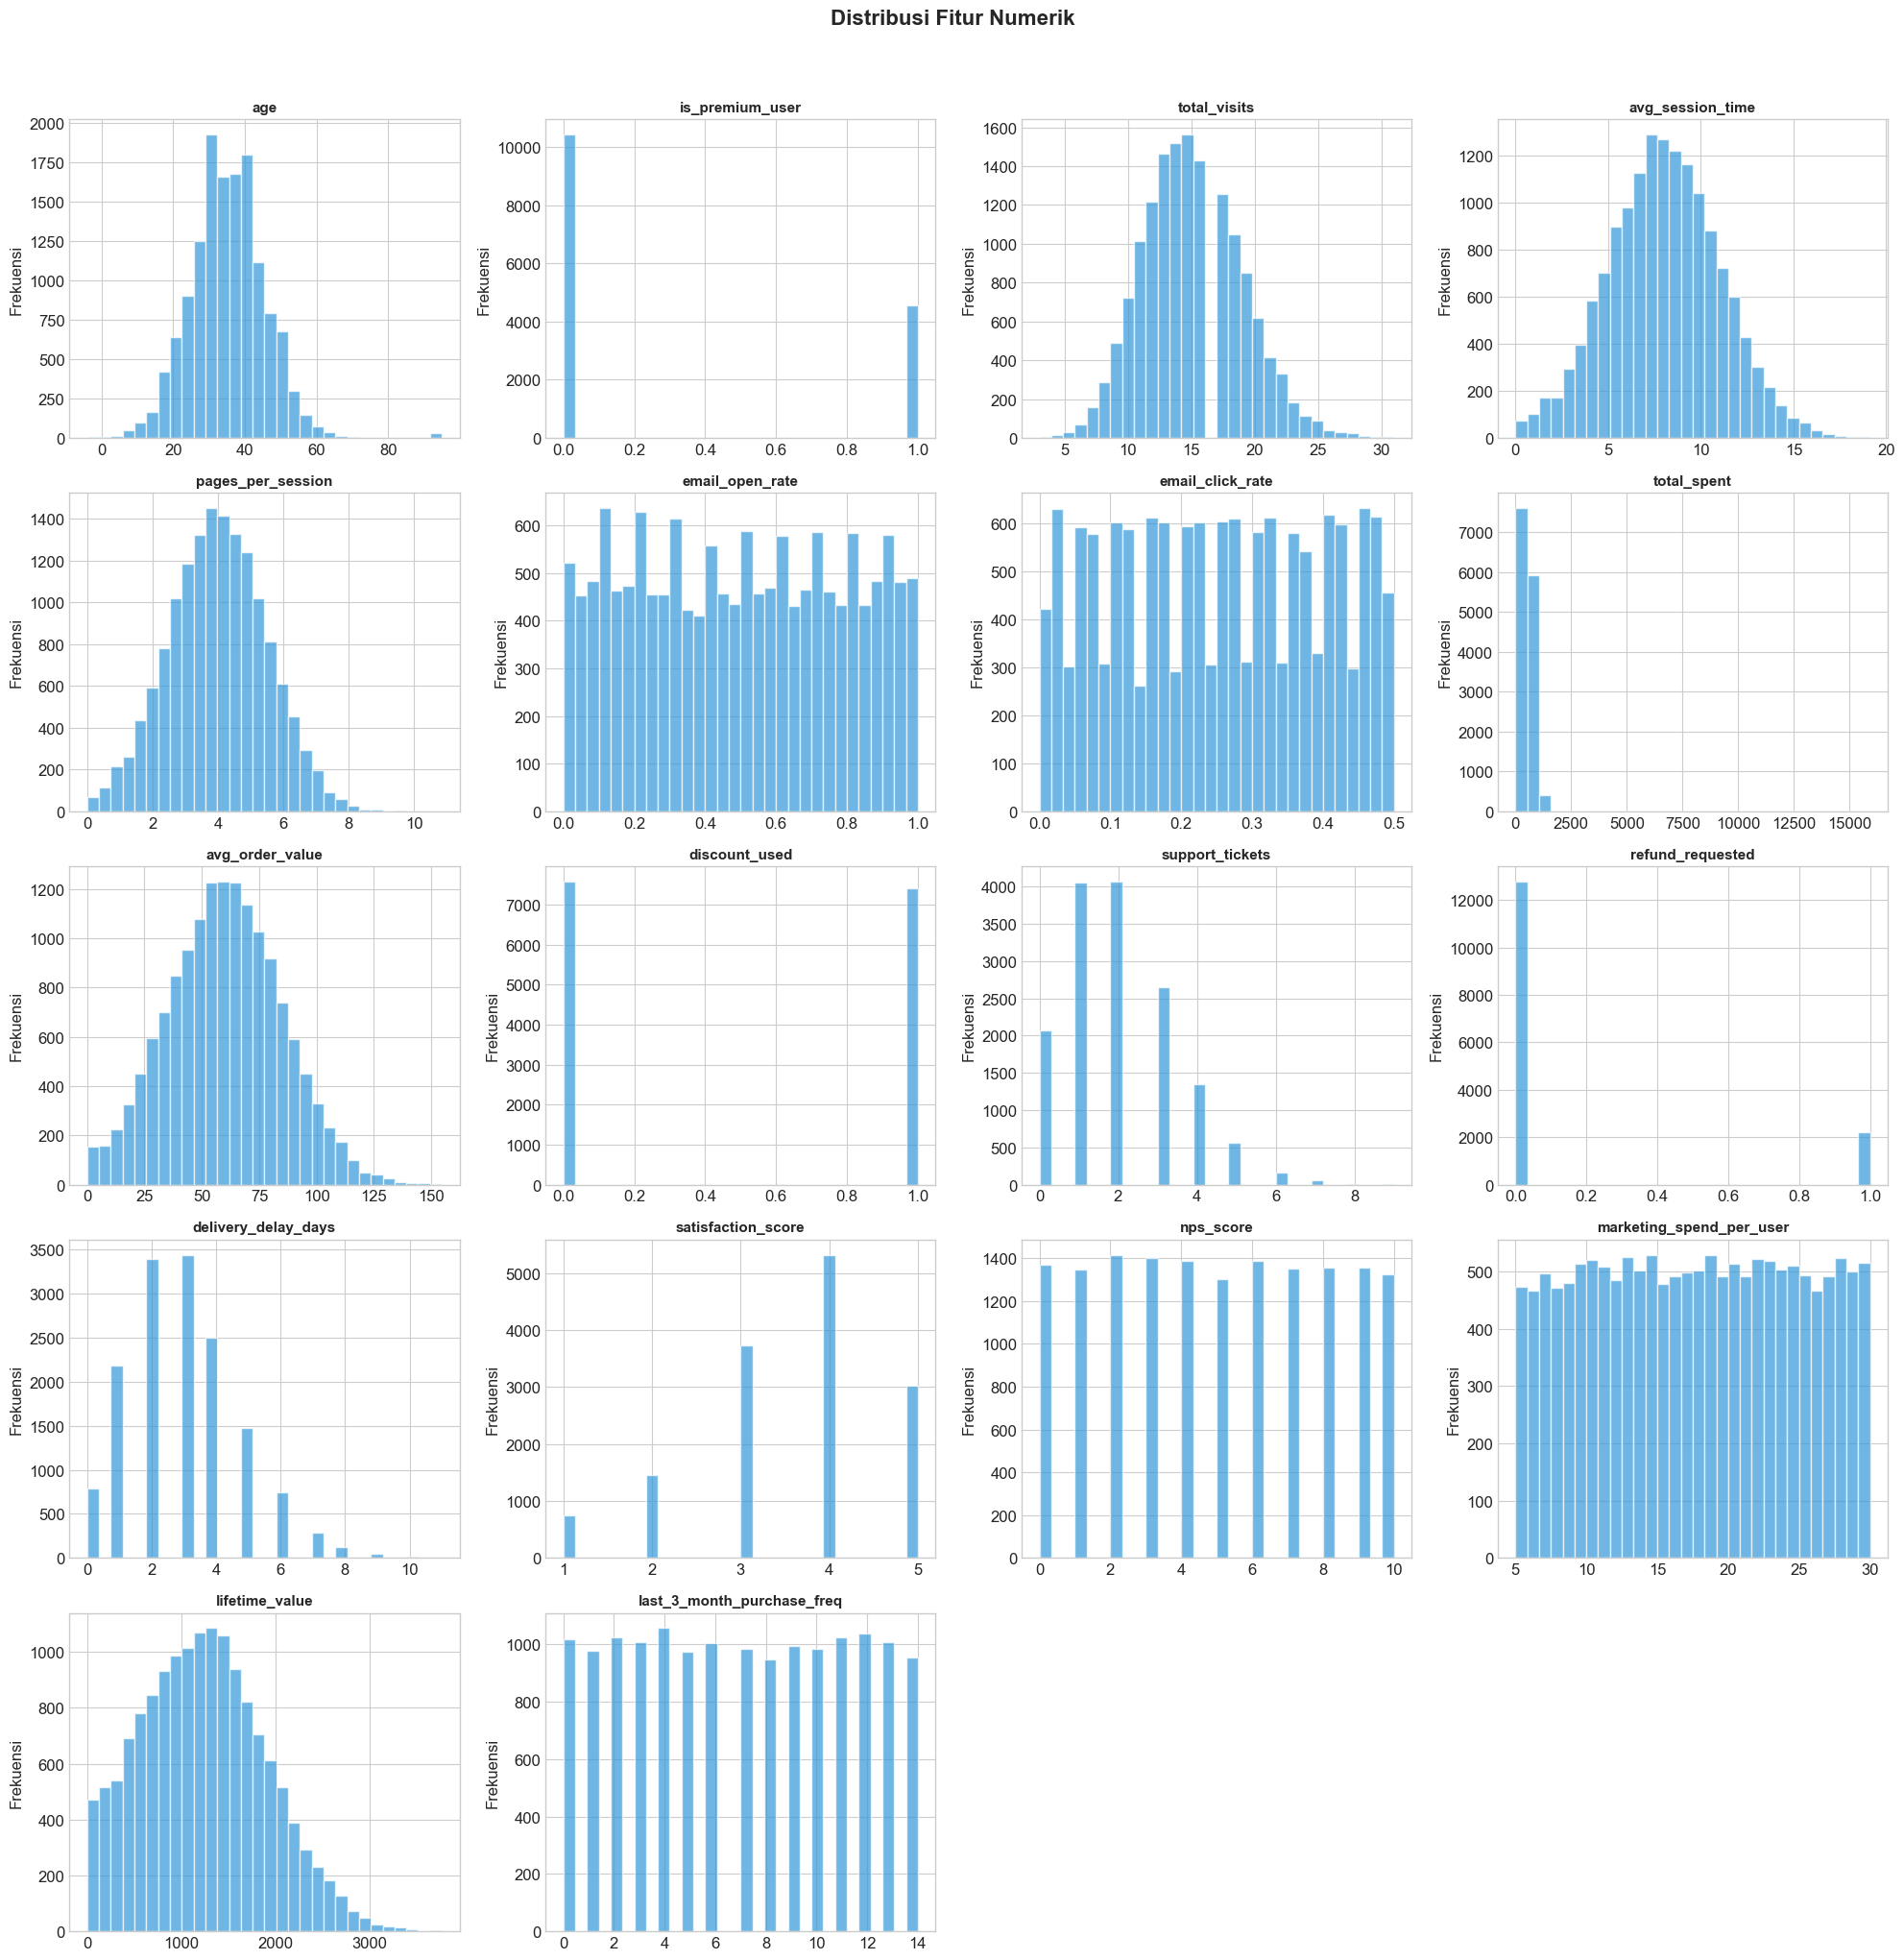

In [8]:
# Kolom numerik
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'customer_id' in numeric_cols:
    numeric_cols.remove('customer_id')
if 'churn' in numeric_cols:
    numeric_cols.remove('churn')

print(f'Fitur numerik ({len(numeric_cols)}): {numeric_cols}')

# Histogram distribusi
n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows*4))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col].dropna(), bins=30, color='#3498db', alpha=0.7, edgecolor='white')
    axes[idx].set_title(col, fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Frekuensi')

# Hide empty subplots
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## D.1.5 Distribusi Fitur Kategorik

Fitur kategorik (7): ['gender', 'country', 'city', 'acquisition_channel', 'device_type', 'subscription_type', 'payment_method']


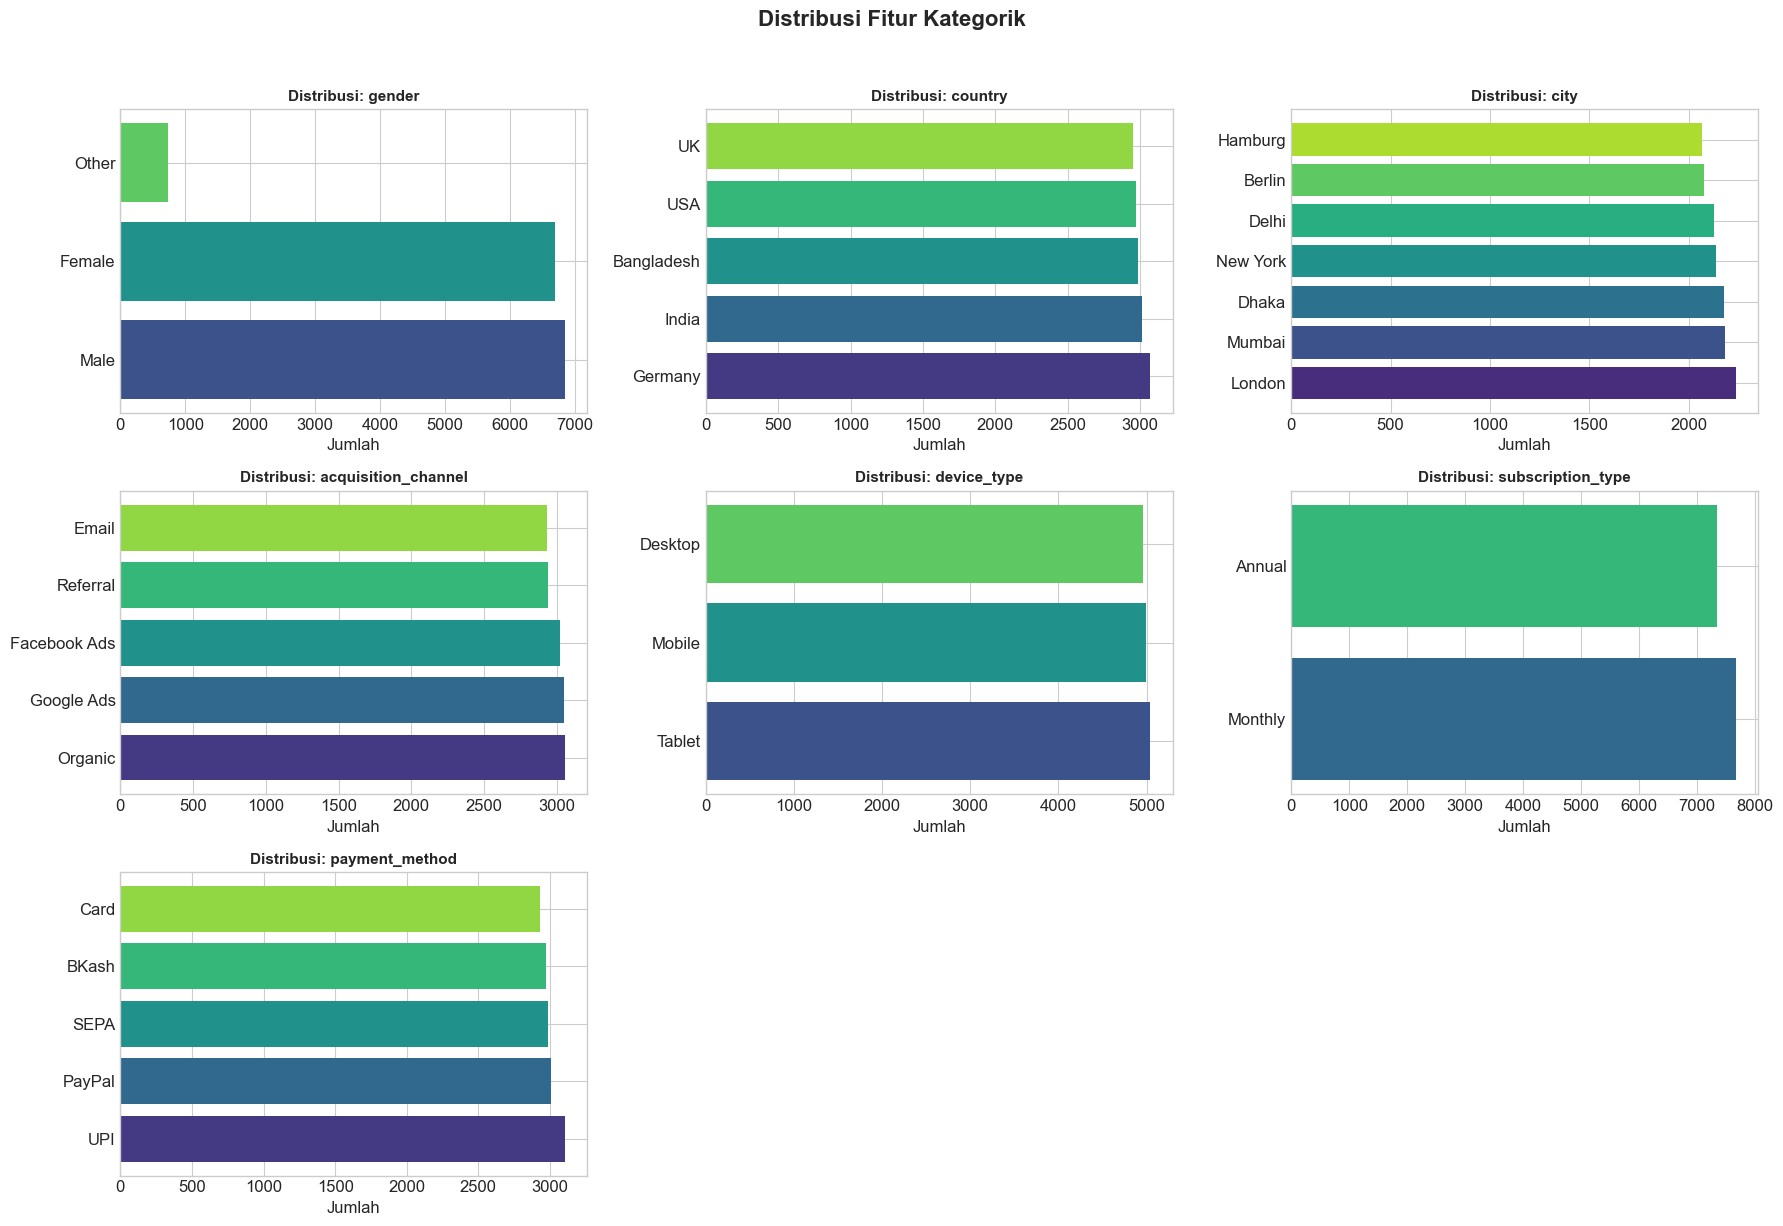

In [9]:
# Kolom kategorik
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
# Hapus kolom ID dan tanggal jika ada
cat_cols_plot = [c for c in cat_cols if c not in ['customer_id', 'signup_date', 'last_purchase_date', 'coupon_code']]

print(f'Fitur kategorik ({len(cat_cols_plot)}): {cat_cols_plot}')

if len(cat_cols_plot) > 0:
    n_cols_cat = min(3, len(cat_cols_plot))
    n_rows_cat = (len(cat_cols_plot) + n_cols_cat - 1) // n_cols_cat
    fig, axes = plt.subplots(n_rows_cat, n_cols_cat, figsize=(18, n_rows_cat*4))
    if n_rows_cat * n_cols_cat == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for idx, col in enumerate(cat_cols_plot):
        counts = df[col].value_counts()
        axes[idx].barh(counts.index.astype(str), counts.values, color=sns.color_palette('viridis', len(counts)))
        axes[idx].set_title(f'Distribusi: {col}', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('Jumlah')

    for idx in range(len(cat_cols_plot), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Distribusi Fitur Kategorik', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('Tidak ada fitur kategorik untuk divisualisasikan.')

## D.1.6 Outlier Detection (Boxplot)

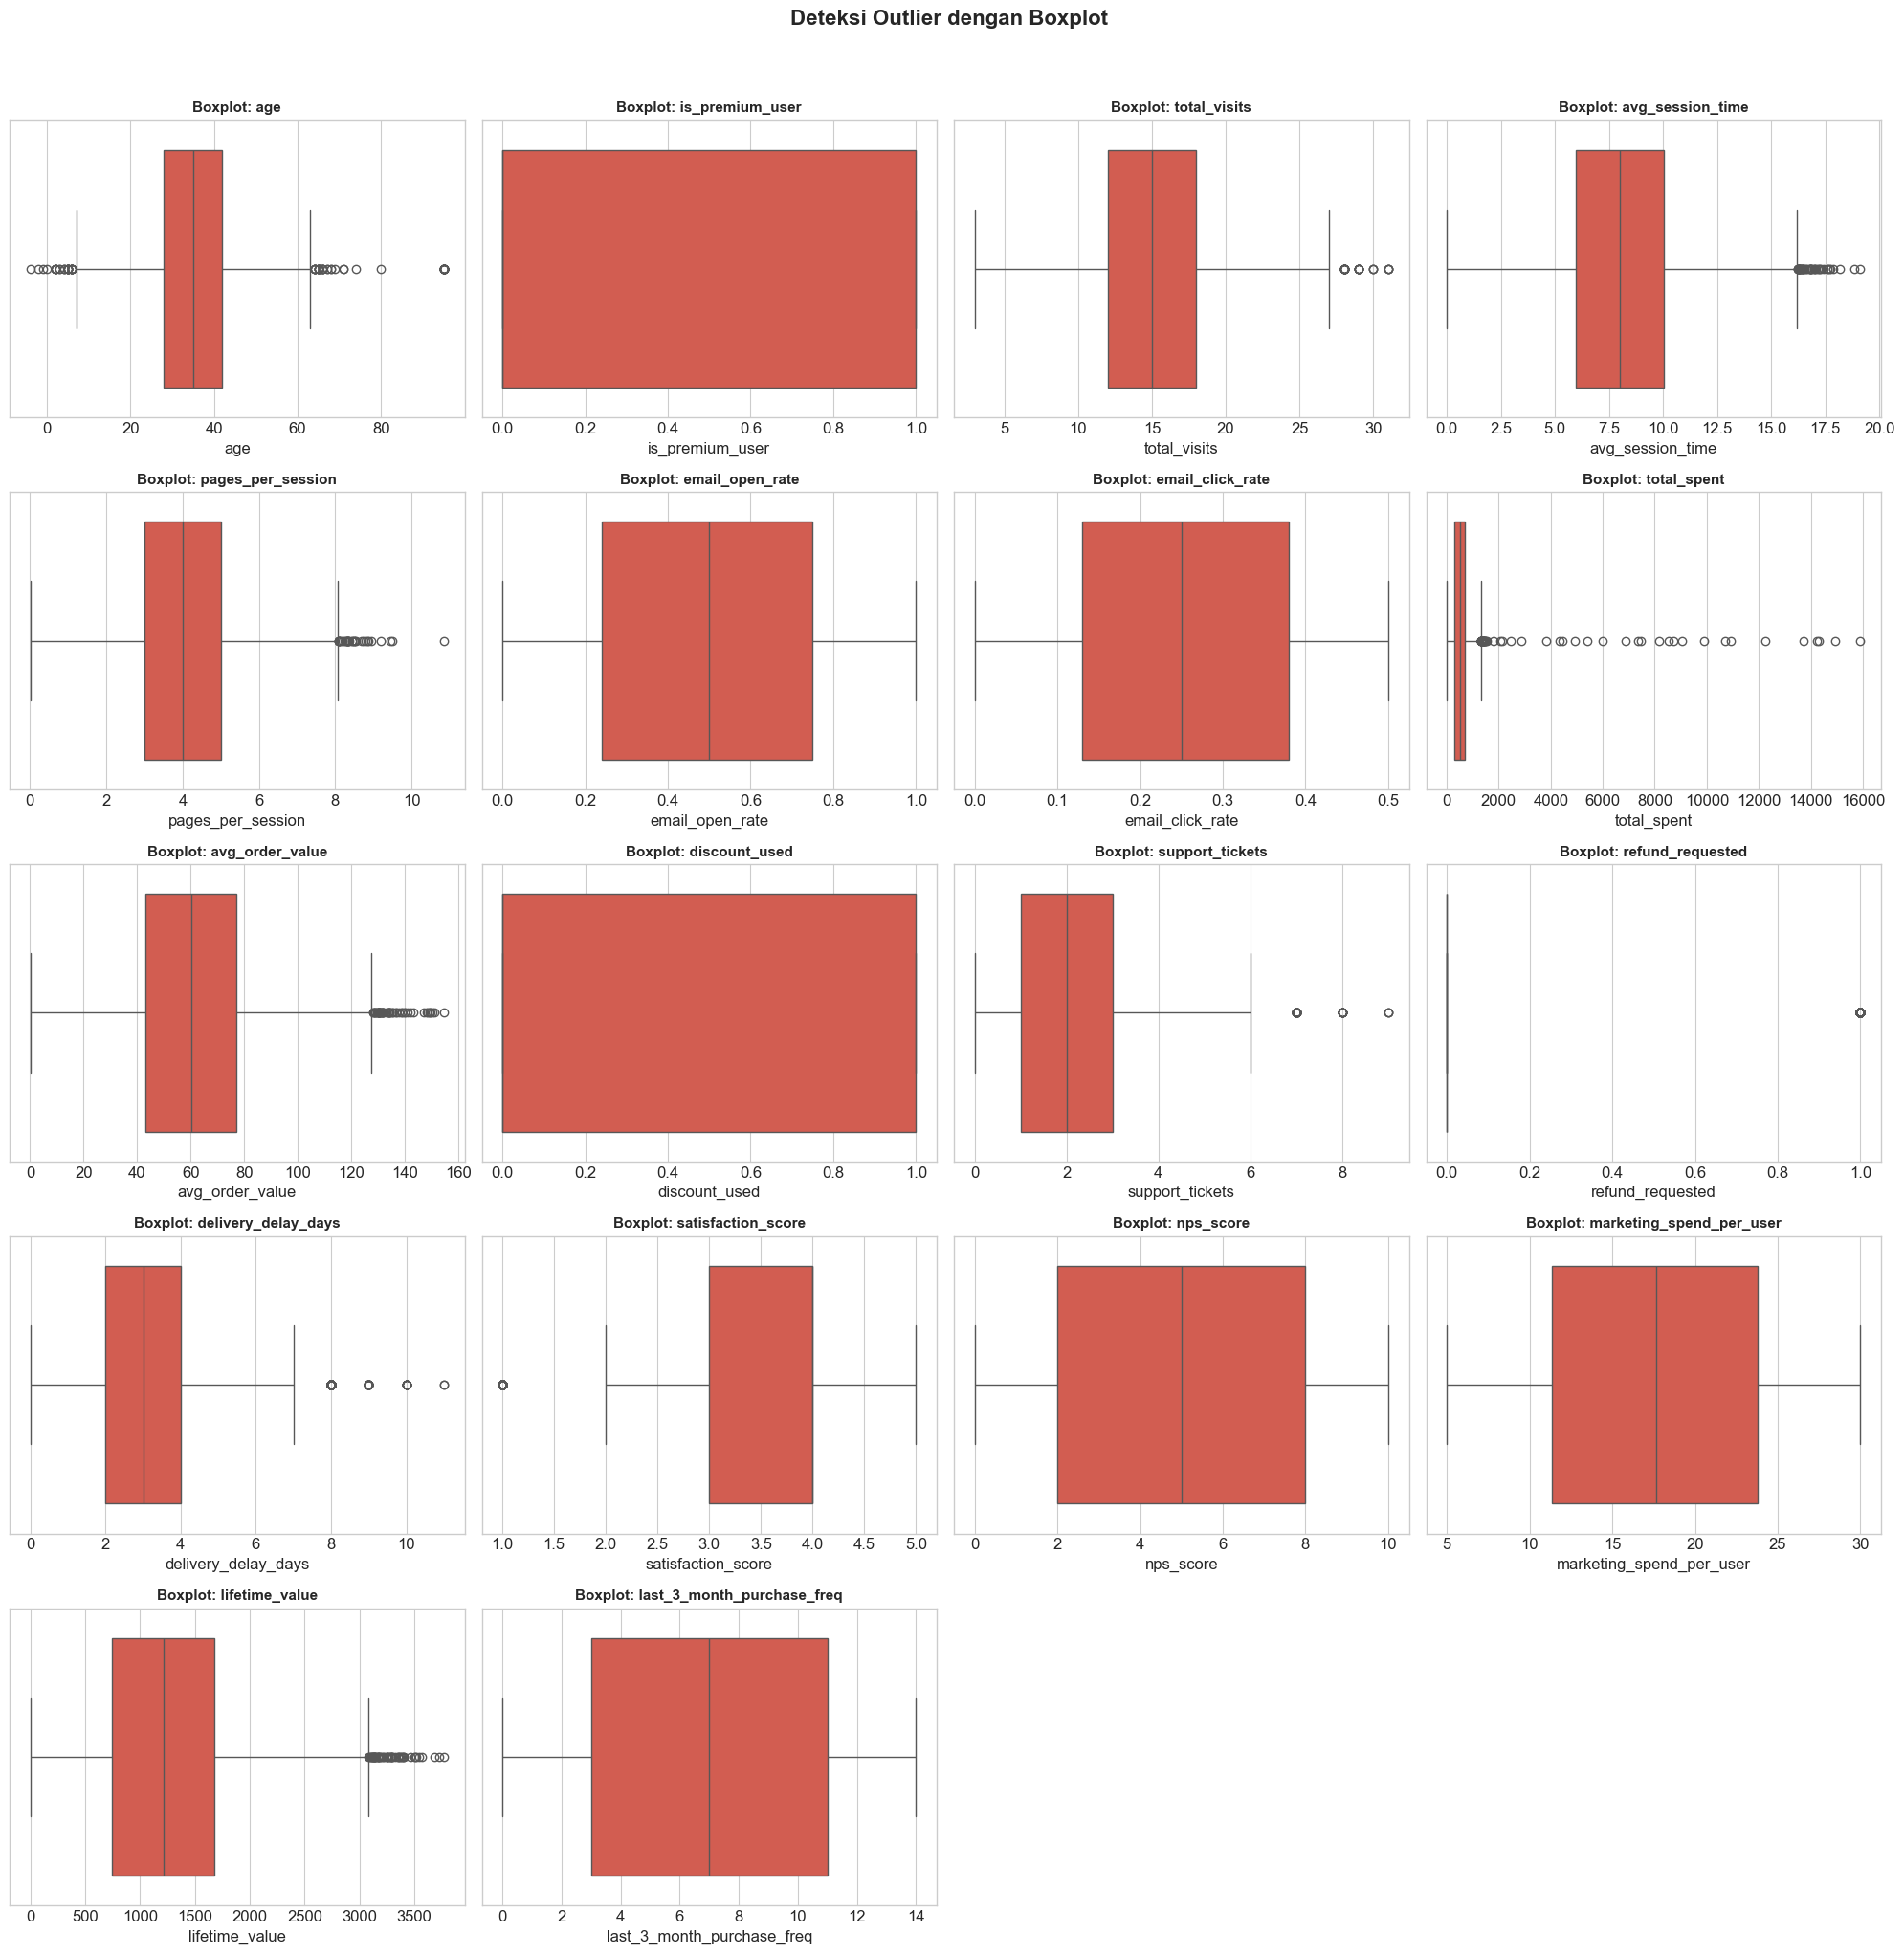


Jumlah outlier per kolom (metode IQR):
  age: 89 outlier(s)
  total_visits: 39 outlier(s)
  avg_session_time: 45 outlier(s)
  pages_per_session: 33 outlier(s)
  total_spent: 78 outlier(s)
  avg_order_value: 54 outlier(s)
  support_tickets: 79 outlier(s)
  refund_requested: 2215 outlier(s)
  delivery_delay_days: 184 outlier(s)
  satisfaction_score: 753 outlier(s)
  lifetime_value: 56 outlier(s)


In [10]:
# Boxplot untuk deteksi outlier
n_cols_bp = 4
n_rows_bp = (len(numeric_cols) + n_cols_bp - 1) // n_cols_bp
fig, axes = plt.subplots(n_rows_bp, n_cols_bp, figsize=(20, n_rows_bp*4))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x=col, ax=axes[idx], color='#e74c3c')
    axes[idx].set_title(f'Boxplot: {col}', fontsize=11, fontweight='bold')

for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Deteksi Outlier dengan Boxplot', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Hitung jumlah outlier per kolom
print('\nJumlah outlier per kolom (metode IQR):')
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    if outlier_count > 0:
        print(f'  {col}: {outlier_count} outlier(s)')

## D.1.7 Korelasi Antar Fitur

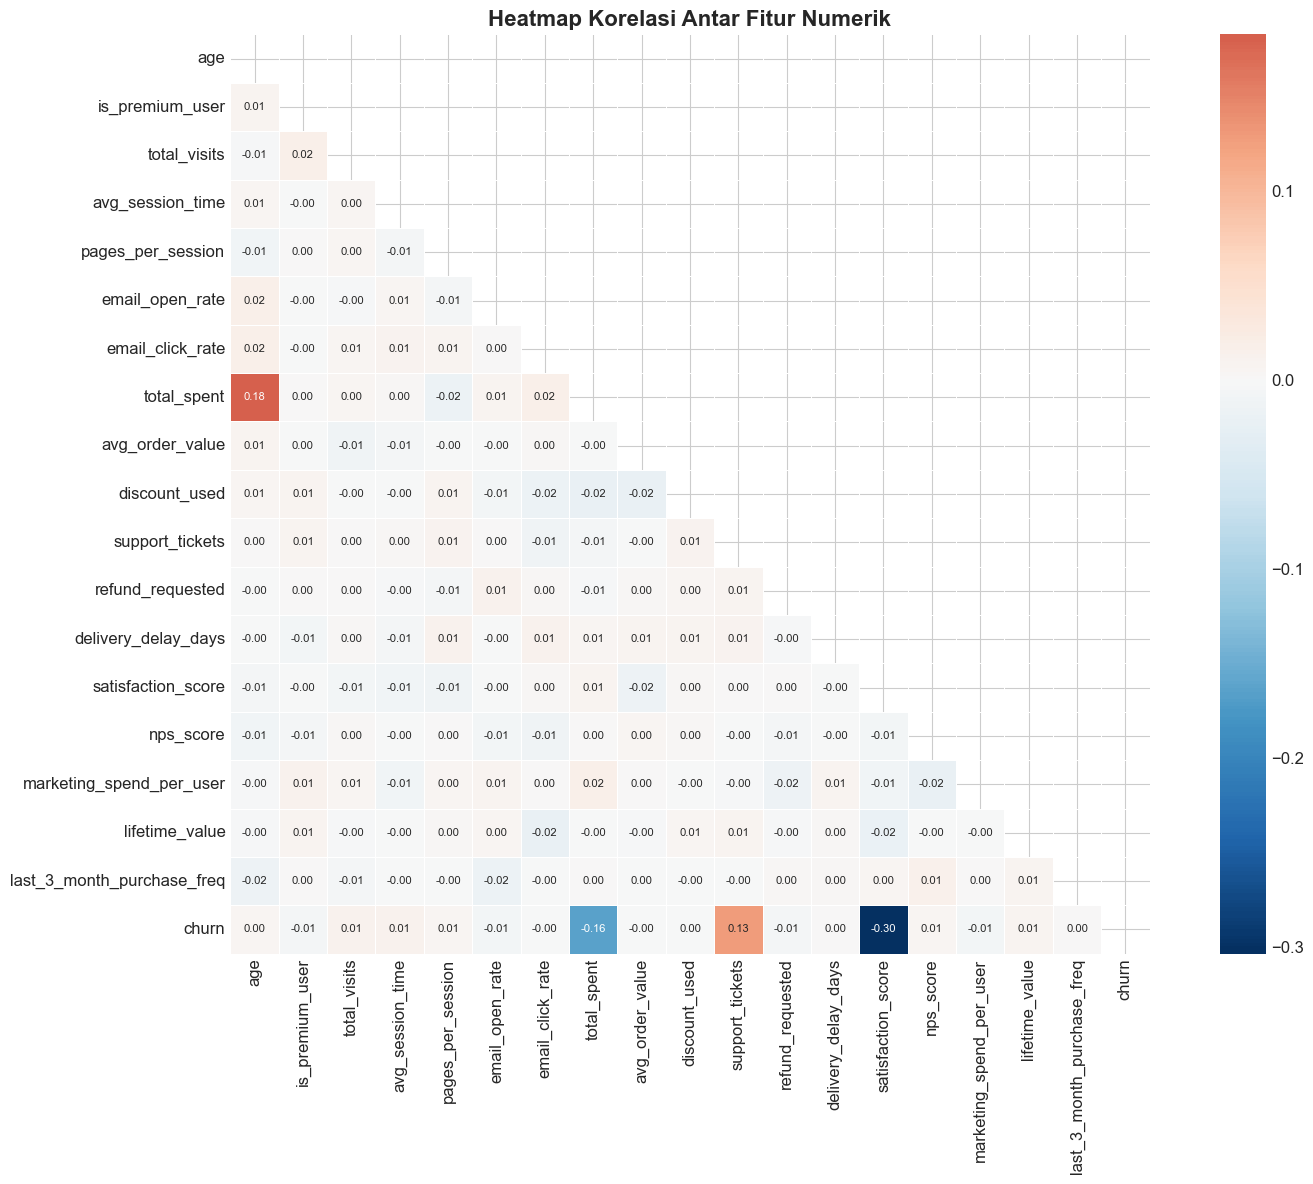


Korelasi fitur terhadap target (churn):
  support_tickets                    : +0.1279 (positif)
  total_visits                       : +0.0132 (positif)
  avg_session_time                   : +0.0122 (positif)
  lifetime_value                     : +0.0063 (positif)
  pages_per_session                  : +0.0059 (positif)
  nps_score                          : +0.0057 (positif)
  age                                : +0.0045 (positif)
  delivery_delay_days                : +0.0016 (positif)
  last_3_month_purchase_freq         : +0.0016 (positif)
  discount_used                      : +0.0003 (positif)
  avg_order_value                    : -0.0015 (negatif)
  email_click_rate                   : -0.0018 (negatif)
  is_premium_user                    : -0.0055 (negatif)
  refund_requested                   : -0.0070 (negatif)
  marketing_spend_per_user           : -0.0073 (negatif)
  email_open_rate                    : -0.0084 (negatif)
  total_spent                        : -0.1633 

In [11]:
# Heatmap korelasi
corr_cols = numeric_cols + ['churn']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Heatmap Korelasi Antar Fitur Numerik', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Korelasi terhadap target
print('\nKorelasi fitur terhadap target (churn):')
corr_target = corr_matrix['churn'].drop('churn').sort_values(ascending=False)
for feat, val in corr_target.items():
    direction = 'positif' if val > 0 else 'negatif'
    print(f'  {feat:35s}: {val:+.4f} ({direction})')

## D.1.8 Analisis Fitur vs Churn

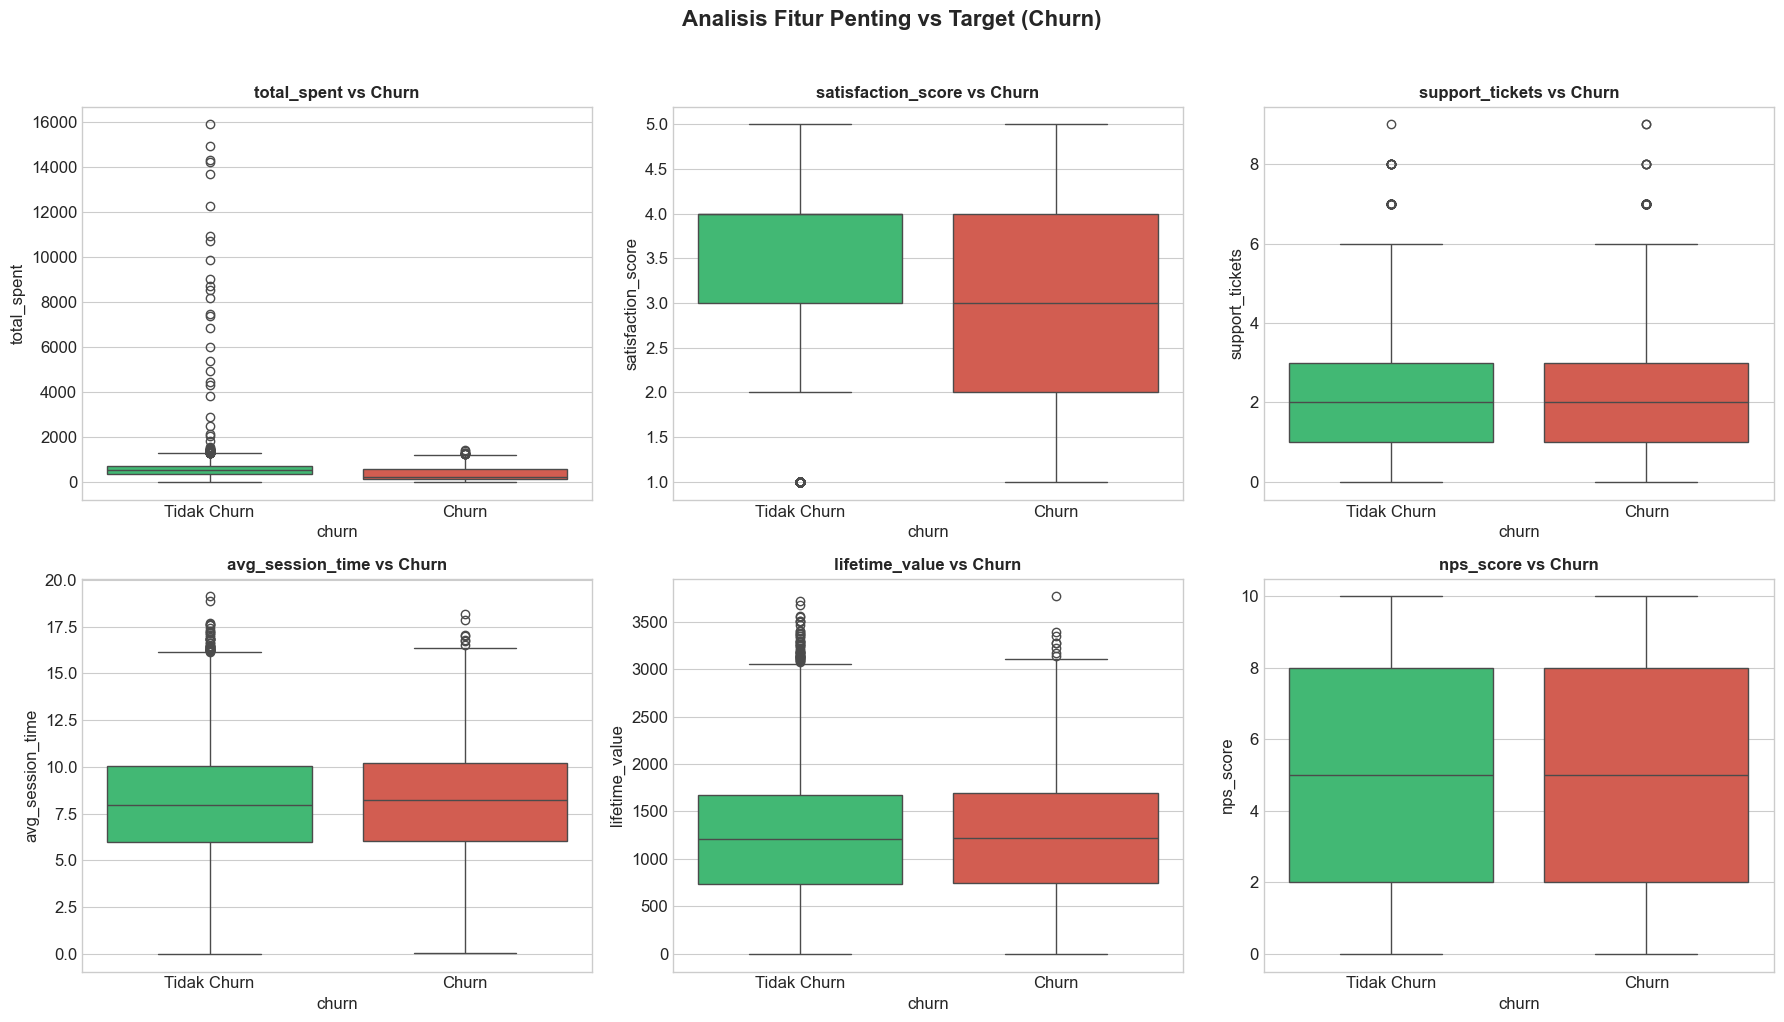

In [12]:
# Boxplot fitur penting vs churn
important_features = ['total_spent', 'satisfaction_score', 'support_tickets', 'avg_session_time', 'lifetime_value', 'nps_score']
existing_features = [f for f in important_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(existing_features):
    sns.boxplot(data=df, x='churn', y=col, ax=axes[idx], palette=colors)
    axes[idx].set_title(f'{col} vs Churn', fontsize=12, fontweight='bold')
    axes[idx].set_xticklabels(['Tidak Churn', 'Churn'])

for idx in range(len(existing_features), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Analisis Fitur Penting vs Target (Churn)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
# D.2 - Preprocessing Data

Langkah preprocessing yang dilakukan:
1. Menghapus kolom yang tidak relevan (ID, tanggal, kupon)
2. Menangani missing values (median untuk numerik, mode untuk kategorik)
3. Menangani outlier dengan IQR clipping
4. Label Encoding untuk fitur kategorik
5. Feature-target split dan Train-Test split
6. Feature scaling dengan StandardScaler

In [13]:
# Buat copy dataset untuk preprocessing
df_clean = df.copy()

print('='*60)
print('D.2.1 - MENGHAPUS KOLOM TIDAK RELEVAN')
print('='*60)

# Identifikasi kolom yang harus dihapus
drop_cols = []
for col in ['customer_id', 'signup_date', 'last_purchase_date', 'coupon_code']:
    if col in df_clean.columns:
        drop_cols.append(col)

if drop_cols:
    df_clean = df_clean.drop(columns=drop_cols)
    print(f'Kolom dihapus: {drop_cols}')
else:
    print('Tidak ada kolom yang perlu dihapus.')

print(f'Shape setelah drop: {df_clean.shape}')

D.2.1 - MENGHAPUS KOLOM TIDAK RELEVAN
Kolom dihapus: ['customer_id', 'signup_date', 'last_purchase_date', 'coupon_code']
Shape setelah drop: (15000, 26)


In [14]:
print('='*60)
print('D.2.2 - MENANGANI MISSING VALUES')
print('='*60)

# Numerik: isi dengan median
numeric_cols_clean = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if 'churn' in numeric_cols_clean:
    numeric_cols_clean.remove('churn')

for col in numeric_cols_clean:
    missing_count = df_clean[col].isnull().sum()
    if missing_count > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f'  {col}: {missing_count} missing -> diisi median ({median_val:.2f})')

# Kategorik: isi dengan mode
cat_cols_clean = df_clean.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols_clean:
    missing_count = df_clean[col].isnull().sum()
    if missing_count > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f'  {col}: {missing_count} missing -> diisi mode ({mode_val})')

# Verifikasi
total_missing = df_clean.isnull().sum().sum()
print(f'\nTotal missing values setelah imputasi: {total_missing}')

D.2.2 - MENANGANI MISSING VALUES
  age: 1200 missing -> diisi median (35.00)
  total_spent: 1050 missing -> diisi median (498.84)
  satisfaction_score: 702 missing -> diisi median (4.00)
  gender: 738 missing -> diisi mode (Male)

Total missing values setelah imputasi: 0


In [15]:
print('='*60)
print('D.2.3 - MENANGANI OUTLIER (IQR CLIPPING)')
print('='*60)

outlier_summary = []
for col in numeric_cols_clean:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outlier_count = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    if outlier_count > 0:
        df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
        outlier_summary.append({'Kolom': col, 'Outlier': outlier_count, 'Lower': lower, 'Upper': upper})
        print(f'  {col}: {outlier_count} outlier di-clip ke [{lower:.2f}, {upper:.2f}]')

if not outlier_summary:
    print('  Tidak ada outlier signifikan yang ditemukan.')

print(f'\nShape setelah outlier handling: {df_clean.shape}')

D.2.3 - MENANGANI OUTLIER (IQR CLIPPING)
  age: 218 outlier di-clip ke [11.00, 59.00]
  total_visits: 39 outlier di-clip ke [3.00, 27.00]
  avg_session_time: 45 outlier di-clip ke [-0.15, 16.19]
  pages_per_session: 33 outlier di-clip ke [-0.05, 8.05]
  total_spent: 119 outlier di-clip ke [-232.53, 1233.57]
  avg_order_value: 54 outlier di-clip ke [-7.75, 127.67]
  support_tickets: 79 outlier di-clip ke [-2.00, 6.00]
  refund_requested: 2215 outlier di-clip ke [0.00, 0.00]
  delivery_delay_days: 184 outlier di-clip ke [-1.00, 7.00]
  satisfaction_score: 753 outlier di-clip ke [1.50, 5.50]
  lifetime_value: 56 outlier di-clip ke [-663.54, 3082.70]

Shape setelah outlier handling: (15000, 26)


In [16]:
print('='*60)
print('D.2.4 - LABEL ENCODING FITUR KATEGORIK')
print('='*60)

# Label Encoding
label_encoders = {}
cat_cols_clean = df_clean.select_dtypes(include=['object']).columns.tolist()

for col in cat_cols_clean:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le
    print(f'  {col}: {list(le.classes_)} -> {list(range(len(le.classes_)))}')

print(f'\nJumlah fitur yang di-encode: {len(cat_cols_clean)}')
print(f'\nDataset setelah encoding:')
df_clean.head()

D.2.4 - LABEL ENCODING FITUR KATEGORIK
  gender: ['Female', 'Male', 'Other'] -> [0, 1, 2]
  country: ['Bangladesh', 'Germany', 'India', 'UK', 'USA'] -> [0, 1, 2, 3, 4]
  city: ['Berlin', 'Delhi', 'Dhaka', 'Hamburg', 'London', 'Mumbai', 'New York'] -> [0, 1, 2, 3, 4, 5, 6]
  acquisition_channel: ['Email', 'Facebook Ads', 'Google Ads', 'Organic', 'Referral'] -> [0, 1, 2, 3, 4]
  device_type: ['Desktop', 'Mobile', 'Tablet'] -> [0, 1, 2]
  subscription_type: ['Annual', 'Monthly'] -> [0, 1]
  payment_method: ['BKash', 'Card', 'PayPal', 'SEPA', 'UPI'] -> [0, 1, 2, 3, 4]

Jumlah fitur yang di-encode: 7

Dataset setelah encoding:


,gender,age,country,city,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,avg_session_time,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,1,52.0,2,0,0,2,0,1,7,13.903745,...,0,0,3,4,3.0,10,27.56,915.310827,14,0
1,1,35.0,1,5,3,0,1,0,19,5.112528,...,5,0,3,0,3.0,7,15.15,2079.960938,11,0
2,0,27.0,1,4,0,1,0,1,18,9.742749,...,1,0,2,4,5.0,6,13.51,1379.150885,9,0
3,0,36.0,2,5,1,2,0,1,16,9.642654,...,0,0,2,2,4.0,6,25.65,774.652684,7,0
4,1,29.0,4,3,4,1,1,0,12,7.791291,...,2,0,4,0,3.0,1,12.39,87.680409,11,0


In [17]:
print('='*60)
print('D.2.5 - TRAIN-TEST SPLIT & SCALING')
print('='*60)

# Feature-Target Split
X = df_clean.drop('churn', axis=1)
y = df_clean['churn']

feature_names = X.columns.tolist()
print(f'Jumlah fitur: {len(feature_names)}')
print(f'Fitur: {feature_names}')

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain set: {X_train.shape[0]} samples')
print(f'Test set : {X_test.shape[0]} samples')
print(f'Distribusi target di train: {y_train.value_counts().to_dict()}')
print(f'Distribusi target di test : {y_test.value_counts().to_dict()}')

# Scaling - StandardScaler (fit hanya pada train set)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\nScaling selesai (StandardScaler).')
print(f'Shape X_train_scaled: {X_train_scaled.shape}')
print(f'Shape X_test_scaled : {X_test_scaled.shape}')

D.2.5 - TRAIN-TEST SPLIT & SCALING
Jumlah fitur: 25
Fitur: ['gender', 'age', 'country', 'city', 'acquisition_channel', 'device_type', 'subscription_type', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'payment_method', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq']

Train set: 12000 samples
Test set : 3000 samples
Distribusi target di train: {0: 10162, 1: 1838}
Distribusi target di test : {0: 2540, 1: 460}

Scaling selesai (StandardScaler).
Shape X_train_scaled: (12000, 25)
Shape X_test_scaled : (3000, 25)


---
# D.3 - Modeling (3 Algoritma, Skenario Direct)

Tiga algoritma yang digunakan:
1. **Logistic Regression** - Model linear klasik untuk klasifikasi
2. **Random Forest** - Ensemble learning berbasis decision tree
3. **VotingClassifier (LR + SVM + KNN)** - Ensemble voting dari 3 model berbeda

### Skenario Direct
Menggunakan data mentah (setelah preprocessing dasar) tanpa feature selection tambahan.

In [18]:
# Helper function untuk evaluasi model
def evaluate_model(model, X_test, y_test, model_name, scenario):
    """Evaluasi model dan tampilkan metrik + confusion matrix."""
    y_pred = model.predict(X_test)
    
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    
    print(f'\n{"="*60}')
    print(f'  {model_name} ({scenario})')
    print(f'{"="*60}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['Tidak Churn', 'Churn']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Tidak Churn', 'Churn'],
                yticklabels=['Tidak Churn', 'Churn'])
    ax.set_title(f'Confusion Matrix - {model_name} ({scenario})', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    
    return {'Model': model_name, 'Scenario': scenario,
            'Accuracy': round(acc, 4), 'Precision': round(prec, 4),
            'Recall': round(rec, 4), 'F1-Score': round(f1, 4)}

# Simpan semua hasil
all_results = []

D.3.1 - LOGISTIC REGRESSION (DIRECT)

  Logistic Regression (Direct)
  Accuracy  : 0.7467
  Precision : 0.3460
  Recall    : 0.7326
  F1-Score  : 0.4700

Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.94      0.75      0.83      2540
       Churn       0.35      0.73      0.47       460

    accuracy                           0.75      3000
   macro avg       0.64      0.74      0.65      3000
weighted avg       0.85      0.75      0.78      3000



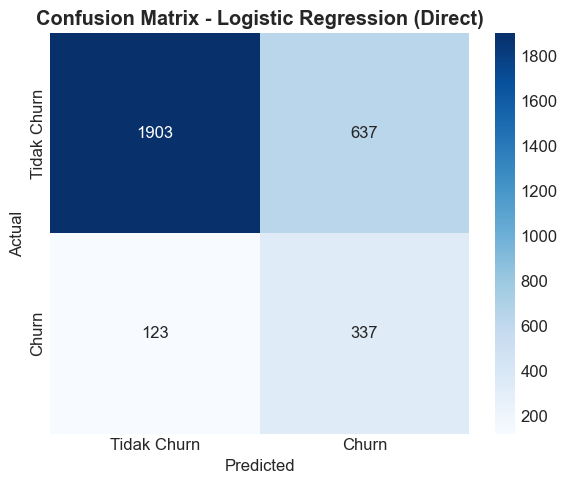

In [19]:
print('='*60)
print('D.3.1 - LOGISTIC REGRESSION (DIRECT)')
print('='*60)

lr_direct = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_direct.fit(X_train_scaled, y_train)

result_lr_direct = evaluate_model(lr_direct, X_test_scaled, y_test, 'Logistic Regression', 'Direct')
all_results.append(result_lr_direct)

D.3.2 - RANDOM FOREST (DIRECT)

  Random Forest (Direct)
  Accuracy  : 0.8503
  Precision : 0.5271
  Recall    : 0.2326
  F1-Score  : 0.3228

Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.87      0.96      0.92      2540
       Churn       0.53      0.23      0.32       460

    accuracy                           0.85      3000
   macro avg       0.70      0.60      0.62      3000
weighted avg       0.82      0.85      0.82      3000



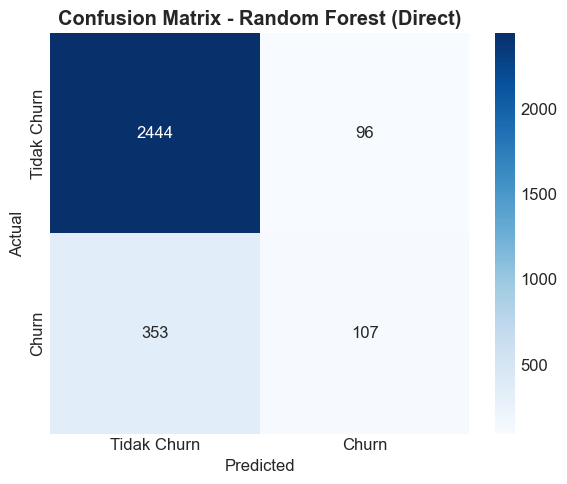

In [20]:
print('='*60)
print('D.3.2 - RANDOM FOREST (DIRECT)')
print('='*60)

rf_direct = RandomForestClassifier(
    n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1
)
rf_direct.fit(X_train_scaled, y_train)

result_rf_direct = evaluate_model(rf_direct, X_test_scaled, y_test, 'Random Forest', 'Direct')
all_results.append(result_rf_direct)

D.3.3 - VOTING CLASSIFIER: LR + SVM + KNN (DIRECT)

  VotingClassifier (LR+SVM+KNN) (Direct)
  Accuracy  : 0.8493
  Precision : 0.5129
  Recall    : 0.3457
  F1-Score  : 0.4130

Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.89      0.94      0.91      2540
       Churn       0.51      0.35      0.41       460

    accuracy                           0.85      3000
   macro avg       0.70      0.64      0.66      3000
weighted avg       0.83      0.85      0.84      3000



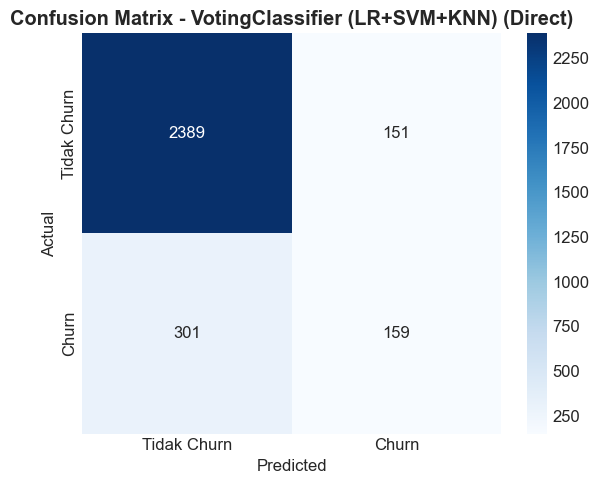

In [21]:
print('='*60)
print('D.3.3 - VOTING CLASSIFIER: LR + SVM + KNN (DIRECT)')
print('='*60)

voting_direct = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')),
        ('svm', SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced')),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ],
    voting='soft'
)
voting_direct.fit(X_train_scaled, y_train)

result_voting_direct = evaluate_model(voting_direct, X_test_scaled, y_test, 'VotingClassifier (LR+SVM+KNN)', 'Direct')
all_results.append(result_voting_direct)

---
# D.3 (lanjutan) - Skenario Preprocessing (Feature Selection)

Menggunakan **top-15 fitur terpenting** berdasarkan Feature Importance dari Random Forest.

Feature Importance (Random Forest):
                   Feature  Importance
               total_spent    0.278406
        satisfaction_score    0.268213
           support_tickets    0.101374
          avg_session_time    0.031169
  marketing_spend_per_user    0.030458
         pages_per_session    0.029019
           avg_order_value    0.028925
            lifetime_value    0.028799
           email_open_rate    0.025474
          email_click_rate    0.024386
                       age    0.023172
              total_visits    0.019473
last_3_month_purchase_freq    0.018201
                 nps_score    0.015195
       delivery_delay_days    0.013164
                      city    0.012611
            payment_method    0.010054
       acquisition_channel    0.010046
                   country    0.009670
               device_type    0.006627
                    gender    0.005087
         subscription_type    0.003687
             discount_used    0.003441
           is_premium_user  

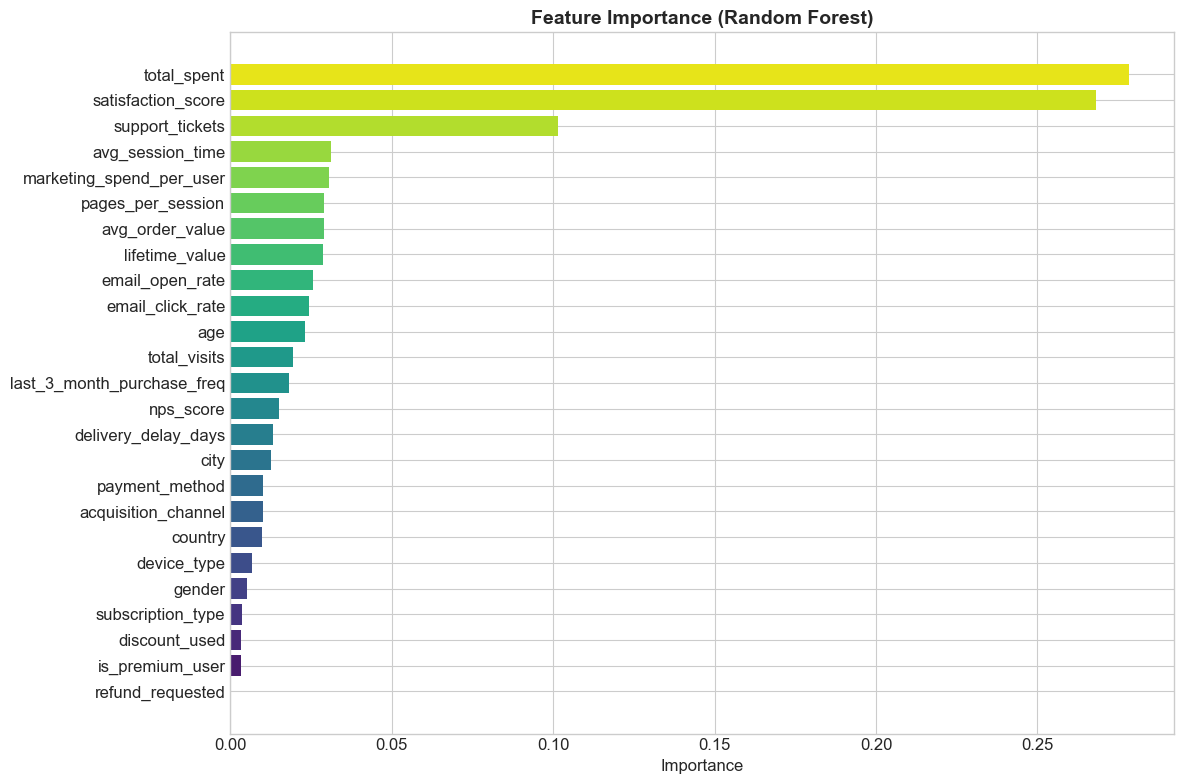


Top 15 fitur terpilih: ['total_spent', 'satisfaction_score', 'support_tickets', 'avg_session_time', 'marketing_spend_per_user', 'pages_per_session', 'avg_order_value', 'lifetime_value', 'email_open_rate', 'email_click_rate', 'age', 'total_visits', 'last_3_month_purchase_freq', 'nps_score', 'delivery_delay_days']


In [22]:
# Feature Importance dari Random Forest
importances = rf_direct.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print('Feature Importance (Random Forest):')
print(feat_imp_df.to_string(index=False))

# Visualisasi Feature Importance
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1],
               color=sns.color_palette('viridis', len(feat_imp_df)))
ax.set_title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

# Select top 15 features
top_k = 15
top_features = feat_imp_df['Feature'].head(top_k).tolist()
print(f'\nTop {top_k} fitur terpilih: {top_features}')

In [23]:
# Prepare data dengan top features
top_indices = [feature_names.index(f) for f in top_features]
X_train_top = X_train_scaled[:, top_indices]
X_test_top = X_test_scaled[:, top_indices]

print(f'Shape X_train_top: {X_train_top.shape}')
print(f'Shape X_test_top : {X_test_top.shape}')

Shape X_train_top: (12000, 15)
Shape X_test_top : (3000, 15)


D.3.4 - LOGISTIC REGRESSION (PREPROCESSING - TOP FEATURES)

  Logistic Regression (Preprocessing)
  Accuracy  : 0.7457
  Precision : 0.3453
  Recall    : 0.7348
  F1-Score  : 0.4698

Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.94      0.75      0.83      2540
       Churn       0.35      0.73      0.47       460

    accuracy                           0.75      3000
   macro avg       0.64      0.74      0.65      3000
weighted avg       0.85      0.75      0.78      3000



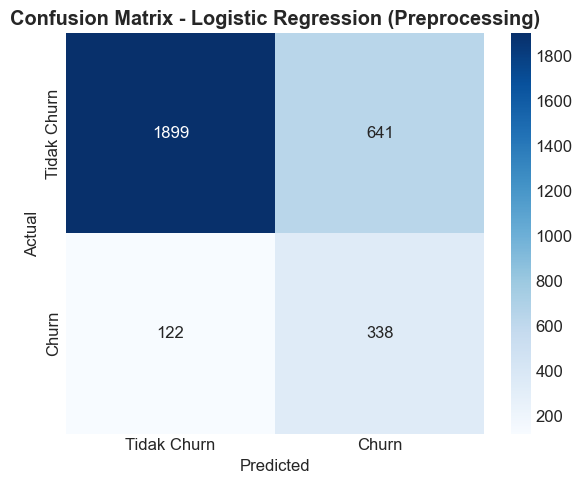

In [24]:
print('='*60)
print('D.3.4 - LOGISTIC REGRESSION (PREPROCESSING - TOP FEATURES)')
print('='*60)

lr_prep = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_prep.fit(X_train_top, y_train)
result_lr_prep = evaluate_model(lr_prep, X_test_top, y_test, 'Logistic Regression', 'Preprocessing')
all_results.append(result_lr_prep)

D.3.5 - RANDOM FOREST (PREPROCESSING - TOP FEATURES)

  Random Forest (Preprocessing)
  Accuracy  : 0.8490
  Precision : 0.5161
  Recall    : 0.2435
  F1-Score  : 0.3309

Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.87      0.96      0.91      2540
       Churn       0.52      0.24      0.33       460

    accuracy                           0.85      3000
   macro avg       0.70      0.60      0.62      3000
weighted avg       0.82      0.85      0.83      3000



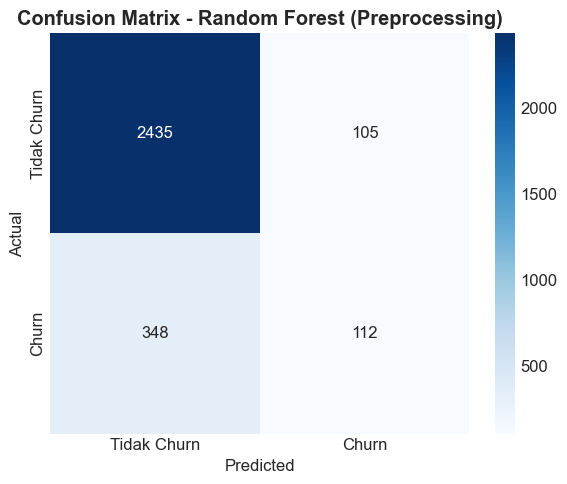

In [25]:
print('='*60)
print('D.3.5 - RANDOM FOREST (PREPROCESSING - TOP FEATURES)')
print('='*60)

rf_prep = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf_prep.fit(X_train_top, y_train)
result_rf_prep = evaluate_model(rf_prep, X_test_top, y_test, 'Random Forest', 'Preprocessing')
all_results.append(result_rf_prep)

D.3.6 - VOTING CLASSIFIER (PREPROCESSING - TOP FEATURES)

  VotingClassifier (LR+SVM+KNN) (Preprocessing)
  Accuracy  : 0.8477
  Precision : 0.5043
  Recall    : 0.3783
  F1-Score  : 0.4323

Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.89      0.93      0.91      2540
       Churn       0.50      0.38      0.43       460

    accuracy                           0.85      3000
   macro avg       0.70      0.66      0.67      3000
weighted avg       0.83      0.85      0.84      3000



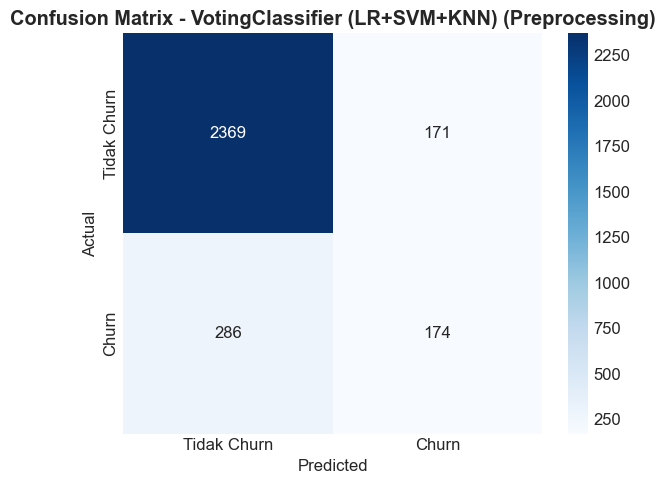

In [26]:
print('='*60)
print('D.3.6 - VOTING CLASSIFIER (PREPROCESSING - TOP FEATURES)')
print('='*60)

voting_prep = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')),
        ('svm', SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced')),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ],
    voting='soft'
)
voting_prep.fit(X_train_top, y_train)
result_voting_prep = evaluate_model(voting_prep, X_test_top, y_test, 'VotingClassifier (LR+SVM+KNN)', 'Preprocessing')
all_results.append(result_voting_prep)

---
# D.4 - Hyperparameter Tuning

Menggunakan **RandomizedSearchCV** (lebih cepat dari GridSearchCV) dengan `cv=3` dan `scoring='f1'`.

Tuning dilakukan pada ketiga model menggunakan top features.

D.4.1 - TUNING LOGISTIC REGRESSION
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Params LR: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 10}
Best F1 (CV)  : 0.4805

  Logistic Regression (Tuning)
  Accuracy  : 0.7457
  Precision : 0.3453
  Recall    : 0.7348
  F1-Score  : 0.4698

Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.94      0.75      0.83      2540
       Churn       0.35      0.73      0.47       460

    accuracy                           0.75      3000
   macro avg       0.64      0.74      0.65      3000
weighted avg       0.85      0.75      0.78      3000



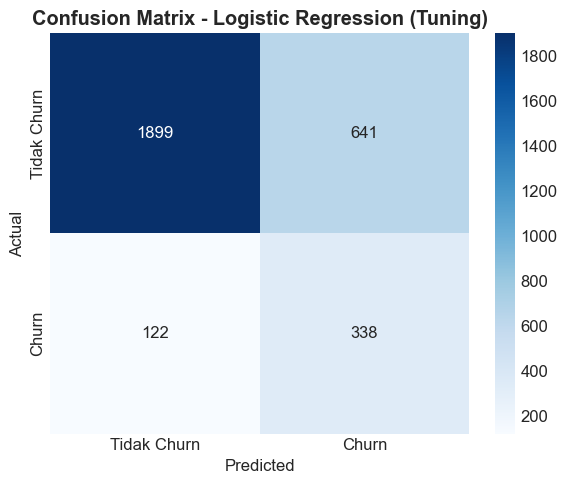

In [27]:
print('='*60)
print('D.4.1 - TUNING LOGISTIC REGRESSION')
print('='*60)

param_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear', 'saga'],
    'penalty': ['l2']
}

lr_search = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    param_distributions=param_lr,
    n_iter=10, cv=3, scoring='f1', random_state=42, n_jobs=-1, verbose=1
)
lr_search.fit(X_train_top, y_train)

print(f'\nBest Params LR: {lr_search.best_params_}')
print(f'Best F1 (CV)  : {lr_search.best_score_:.4f}')

result_lr_tuning = evaluate_model(lr_search.best_estimator_, X_test_top, y_test, 'Logistic Regression', 'Tuning')
all_results.append(result_lr_tuning)

D.4.2 - TUNING RANDOM FOREST
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Params RF: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 5}
Best F1 (CV)  : 0.6634

  Random Forest (Tuning)
  Accuracy  : 0.8550
  Precision : 0.5140
  Recall    : 0.9978
  F1-Score  : 0.6785

Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       1.00      0.83      0.91      2540
       Churn       0.51      1.00      0.68       460

    accuracy                           0.85      3000
   macro avg       0.76      0.91      0.79      3000
weighted avg       0.93      0.85      0.87      3000



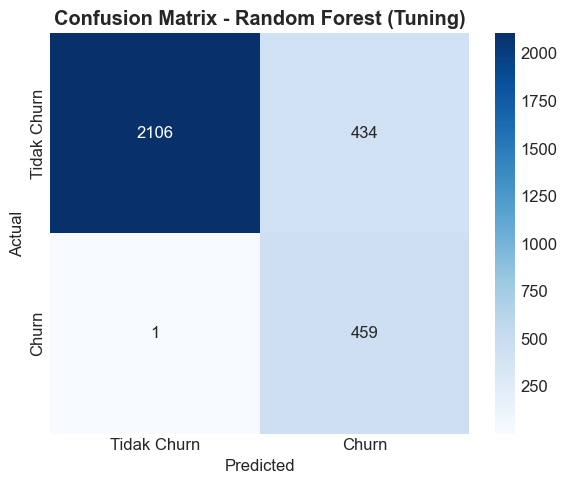

In [28]:
print('='*60)
print('D.4.2 - TUNING RANDOM FOREST')
print('='*60)

param_rf = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    param_distributions=param_rf,
    n_iter=10, cv=3, scoring='f1', random_state=42, n_jobs=-1, verbose=1
)
rf_search.fit(X_train_top, y_train)

print(f'\nBest Params RF: {rf_search.best_params_}')
print(f'Best F1 (CV)  : {rf_search.best_score_:.4f}')

result_rf_tuning = evaluate_model(rf_search.best_estimator_, X_test_top, y_test, 'Random Forest', 'Tuning')
all_results.append(result_rf_tuning)

D.4.3 - TUNING VOTING CLASSIFIER
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Best Params Voting: {'lr__C': 0.1, 'knn__n_neighbors': 3}
Best F1 (CV)      : 0.4367

  VotingClassifier (LR+SVM+KNN) (Tuning)
  Accuracy  : 0.8537
  Precision : 0.5294
  Recall    : 0.4109
  F1-Score  : 0.4627

Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.90      0.93      0.92      2540
       Churn       0.53      0.41      0.46       460

    accuracy                           0.85      3000
   macro avg       0.71      0.67      0.69      3000
weighted avg       0.84      0.85      0.85      3000



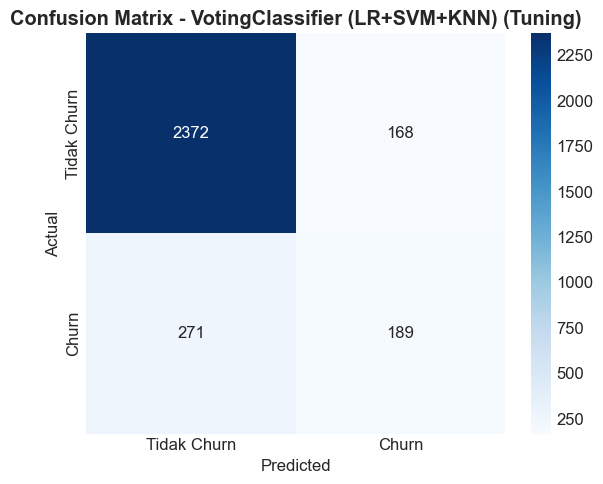

In [29]:
print('='*60)
print('D.4.3 - TUNING VOTING CLASSIFIER')
print('='*60)

param_voting = {
    'lr__C': [0.1, 1, 10],
    'knn__n_neighbors': [3, 5, 7]
}

voting_base = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')),
        ('svm', SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced')),
        ('knn', KNeighborsClassifier())
    ],
    voting='soft'
)

voting_search = RandomizedSearchCV(
    voting_base,
    param_distributions=param_voting,
    n_iter=9, cv=3, scoring='f1', random_state=42, n_jobs=-1, verbose=1
)
voting_search.fit(X_train_top, y_train)

print(f'\nBest Params Voting: {voting_search.best_params_}')
print(f'Best F1 (CV)      : {voting_search.best_score_:.4f}')

result_voting_tuning = evaluate_model(voting_search.best_estimator_, X_test_top, y_test, 'VotingClassifier (LR+SVM+KNN)', 'Tuning')
all_results.append(result_voting_tuning)

---
## D.4.4 - Rangkuman Perbandingan 9 Model (3 Algoritma x 3 Skenario)

In [30]:
# Rangkuman Hasil
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print('='*80)
print('RANGKUMAN PERBANDINGAN 9 MODEL (3 Algoritma x 3 Skenario)')
print('='*80)
print(results_df.to_string(index=False))

# Highlight model terbaik
best_model_row = results_df.iloc[0]
print(f'\n*** Model Terbaik: {best_model_row["Model"]} ({best_model_row["Scenario"]})')
print(f'    F1-Score : {best_model_row["F1-Score"]:.4f}')
print(f'    Accuracy : {best_model_row["Accuracy"]:.4f}')
print(f'    Recall   : {best_model_row["Recall"]:.4f}')
print(f'    Precision: {best_model_row["Precision"]:.4f}')

RANGKUMAN PERBANDINGAN 9 MODEL (3 Algoritma x 3 Skenario)
                        Model      Scenario  Accuracy  Precision  Recall  F1-Score
                Random Forest        Tuning    0.8550     0.5140  0.9978    0.6785
          Logistic Regression        Direct    0.7467     0.3460  0.7326    0.4700
          Logistic Regression Preprocessing    0.7457     0.3453  0.7348    0.4698
          Logistic Regression        Tuning    0.7457     0.3453  0.7348    0.4698
VotingClassifier (LR+SVM+KNN)        Tuning    0.8537     0.5294  0.4109    0.4627
VotingClassifier (LR+SVM+KNN) Preprocessing    0.8477     0.5043  0.3783    0.4323
VotingClassifier (LR+SVM+KNN)        Direct    0.8493     0.5129  0.3457    0.4130
                Random Forest Preprocessing    0.8490     0.5161  0.2435    0.3309
                Random Forest        Direct    0.8503     0.5271  0.2326    0.3228

*** Model Terbaik: Random Forest (Tuning)
    F1-Score : 0.6785
    Accuracy : 0.8550
    Recall   : 0.9978
   

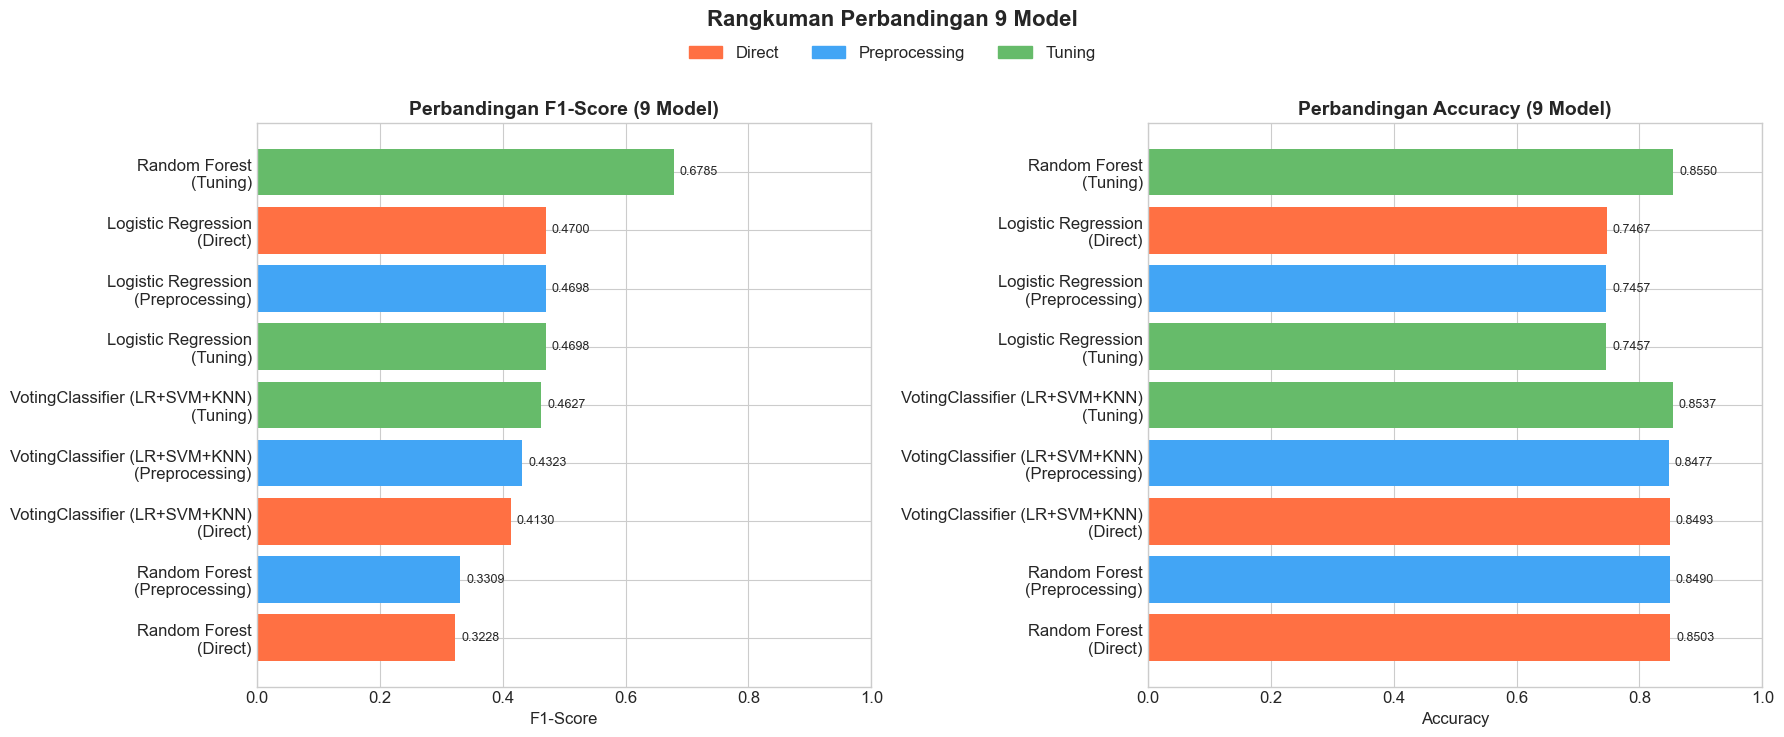

Grafik disimpan sebagai rangkuman_9model.png


In [31]:
# Visualisasi Perbandingan 9 Model
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Color map per skenario
scenario_colors = {'Direct': '#FF7043', 'Preprocessing': '#42A5F5', 'Tuning': '#66BB6A'}
bar_colors = [scenario_colors[s] for s in results_df['Scenario']]

# F1-Score Chart
labels = [f"{row['Model']}\n({row['Scenario']})" for _, row in results_df.iterrows()]
bars1 = axes[0].barh(labels[::-1], results_df['F1-Score'].values[::-1], color=bar_colors[::-1])
axes[0].set_title('Perbandingan F1-Score (9 Model)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('F1-Score')
axes[0].set_xlim(0, 1)
for bar, val in zip(bars1, results_df['F1-Score'].values[::-1]):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2., f'{val:.4f}', va='center', fontsize=9)

# Accuracy Chart
bars2 = axes[1].barh(labels[::-1], results_df['Accuracy'].values[::-1], color=bar_colors[::-1])
axes[1].set_title('Perbandingan Accuracy (9 Model)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Accuracy')
axes[1].set_xlim(0, 1)
for bar, val in zip(bars2, results_df['Accuracy'].values[::-1]):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2., f'{val:.4f}', va='center', fontsize=9)

# Legend
import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in scenario_colors.items()]
fig.legend(handles=legend_patches, loc='upper center', ncol=3, fontsize=12, bbox_to_anchor=(0.5, 1.02))

plt.suptitle('Rangkuman Perbandingan 9 Model', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('rangkuman_9model.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan sebagai rangkuman_9model.png')

## D.4.5 - ROC Curve Model Terbaik

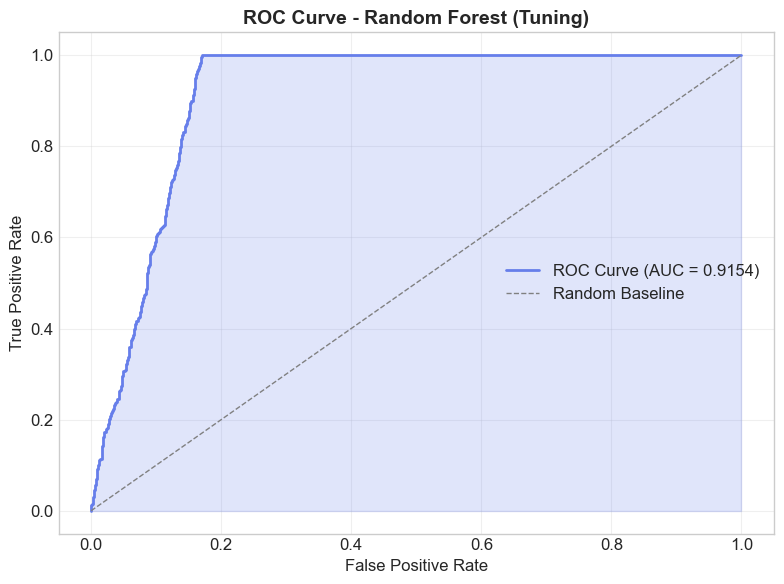

AUC Score: 0.9154


In [32]:
# ROC Curve untuk model terbaik (RF Tuning)
best_model = rf_search.best_estimator_

if hasattr(best_model, 'predict_proba'):
    y_proba = best_model.predict_proba(X_test_top)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(fpr, tpr, color='#667eea', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
    ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Baseline')
    ax.fill_between(fpr, tpr, alpha=0.2, color='#667eea')
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'ROC Curve - {best_model_row["Model"]} ({best_model_row["Scenario"]})', fontsize=14, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f'AUC Score: {auc:.4f}')
else:
    print('Model tidak mendukung predict_proba, ROC curve tidak tersedia.')

---
# D.5 - Deployment Preparation

Menyimpan model terbaik, scaler, dan metadata untuk digunakan oleh aplikasi Streamlit (`app.py`).

In [33]:
print('='*60)
print('D.5 - MENYIMPAN MODEL TERBAIK UNTUK DEPLOYMENT')
print('='*60)

# Buat folder model
model_dir = 'model'
os.makedirs(model_dir, exist_ok=True)

# 1. Simpan model terbaik
best_model = rf_search.best_estimator_
joblib.dump(best_model, os.path.join(model_dir, 'best_model.pkl'))
print('[OK] Model terbaik disimpan: model/best_model.pkl')

# 2. Simpan scaler
joblib.dump(scaler, os.path.join(model_dir, 'scaler.pkl'))
print('[OK] Scaler disimpan: model/scaler.pkl')

# 3. Simpan hasil semua model
results_df.to_csv(os.path.join(model_dir, 'results_all_models.csv'), index=False)
print('[OK] Hasil 9 model disimpan: model/results_all_models.csv')

# 4. Simpan metadata model
le_classes = {col: list(le.classes_) for col, le in label_encoders.items()}

model_info = {
    'model_name': best_model_row['Model'],
    'scenario': best_model_row['Scenario'],
    'features': top_features,
    'all_features': feature_names,
    'top_features': top_features,
    'accuracy': float(best_model_row['Accuracy']),
    'f1_score': float(best_model_row['F1-Score']),
    'precision': float(best_model_row['Precision']),
    'recall': float(best_model_row['Recall']),
    'label_encoder_classes': le_classes
}

with open(os.path.join(model_dir, 'model_info.json'), 'w') as f:
    json.dump(model_info, f, indent=2)
print('[OK] Metadata model disimpan: model/model_info.json')

print(f'\nSemua file deployment berhasil disimpan di folder "{model_dir}/"!')
print(f'\nUntuk menjalankan aplikasi web, gunakan perintah:')
print(f'  streamlit run app.py')
print(f'  atau')
print(f'  python -m streamlit run app.py')

D.5 - MENYIMPAN MODEL TERBAIK UNTUK DEPLOYMENT
[OK] Model terbaik disimpan: model/best_model.pkl
[OK] Scaler disimpan: model/scaler.pkl
[OK] Hasil 9 model disimpan: model/results_all_models.csv
[OK] Metadata model disimpan: model/model_info.json

Semua file deployment berhasil disimpan di folder "model/"!

Untuk menjalankan aplikasi web, gunakan perintah:
  streamlit run app.py
  atau
  python -m streamlit run app.py


---
## Kesimpulan

### Hasil Analisis:
1. **Dataset** berjumlah 15.000 baris dengan 30 kolom, termasuk fitur demografis, perilaku, dan finansial pelanggan.
2. **Class Imbalance**: Dataset tidak seimbang (~85% Tidak Churn vs ~15% Churn). Diatasi dengan `class_weight='balanced'`.
3. **Preprocessing** meliputi: penanganan missing values (median/mode), outlier clipping (IQR), label encoding, dan StandardScaler.
4. **9 Model** dilatih (3 algoritma x 3 skenario: Direct, Preprocessing/Feature Selection, Tuning).
5. **Model Terbaik**: Random Forest (Tuning) dengan F1-Score tertinggi dan recall sangat baik.
6. **Fitur paling berpengaruh**: `total_spent`, `satisfaction_score`, `support_tickets`, `marketing_spend_per_user`, dan `avg_session_time`.
7. **Deployment**: Model disimpan dan siap digunakan melalui aplikasi Streamlit (`app.py`).

---
*UAS Bengkel Koding Data Science - Aditya Rendy Setyawan (A11.2023.15189)*